# Test for FBS scaling with LA

In [1]:
import numpy as np
import xarray as xr
import os
import sys

# main_dir = '/home/s2561233/Documents/Agrifood/ssr_local_authority'

import agrifoodpy
from fbs_la_scaling import fbs_la_scaling

from agrifoodpy_data.land import ONS_LAD_MAY_2025_UK_BUC_1000 as la_land
from agrifoodpy_data.population import UK_ONS_MYE24UK as la_population
from agrifoodpy_data.food import FAOSTAT
from agrifoodpy_data.population import UK_ONS
from agrifoodpy_data.land import UKCEH_LC_1000 as land

In [2]:
fbs = FAOSTAT.sel(Year=2019, Region=229).squeeze(drop=True)
population = UK_ONS.sel(Year=2022, Datatype='Total')

la_id = '314'

In [3]:
# Sort fbs by Item to ensure consistent coordinate ordering
fbs_scaled, land_scaled, population_scaled = fbs_la_scaling(
    fbs,
    population,
    land,
    la_population,
    la_land,
    la_id
)

A few plots to test this

In [11]:
print(fbs)

<xarray.Dataset> Size: 40kB
Dimensions:      (Item: 117)
Coordinates:
  * Item         (Item) int64 936B 2511 2513 2514 2515 ... 2948 2949 2960 2961
    Item_name    (Item) <U31 15kB 'Wheat and products' ... 'Aquatic Products,...
    Item_group   (Item) <U24 11kB 'Cereals - Excluding Beer' ... 'Aquatic Pro...
    Item_origin  (Item) <U16 7kB 'Vegetal Products' ... 'Animal Products'
    Region       int64 8B 229
    Region_name  <U52 208B 'United Kingdom of Great Britain and Northern Irel...
    Year         int64 8B 2019
Data variables: (12/13)
    stock        (Item) float32 468B 1.314e+03 511.0 201.0 0.0 ... 0.0 0.0 nan
    losses       (Item) float32 468B 81.0 40.0 28.0 2.0 5.0 ... 0.0 10.0 nan nan
    processing   (Item) float32 468B 335.0 1.504e+03 844.0 nan ... nan nan nan
    food         (Item) float32 468B 6.789e+03 214.0 470.0 ... 1.216e+03 0.0
    other        (Item) float32 468B 773.0 nan 477.0 nan ... 0.0 0.0 1.21 4.85
    residual     (Item) float32 468B 0.0 0.0 0.0 0.0 0

In [12]:
print(fbs_scaled)


<xarray.Dataset> Size: 44kB
Dimensions:      (Item: 117)
Coordinates:
  * Item         (Item) int64 936B 2511 2513 2514 2515 ... 2948 2949 2960 2961
    Item_name    (Item) <U31 15kB 'Wheat and products' ... 'Aquatic Products,...
    Item_group   (Item) <U24 11kB 'Cereals - Excluding Beer' ... 'Aquatic Pro...
    Item_origin  (Item) <U16 7kB 'Vegetal Products' ... 'Animal Products'
    Region       int64 8B 229
    Region_name  <U52 208B 'United Kingdom of Great Britain and Northern Irel...
    Year         int64 8B 2019
Data variables: (12/13)
    stock        (Item) float64 936B 4.612 1.794 0.7055 0.0 ... 0.0 0.0 nan
    losses       (Item) float64 936B nan nan nan nan nan ... nan nan nan nan nan
    processing   (Item) float64 936B nan nan nan nan nan ... nan nan nan nan nan
    food         (Item) float64 936B 23.83 0.7512 1.65 ... 2.664 4.267 0.0
    other        (Item) float32 468B 773.0 nan 477.0 nan ... 0.0 0.0 1.21 4.85
    residual     (Item) float64 936B nan nan nan nan nan 

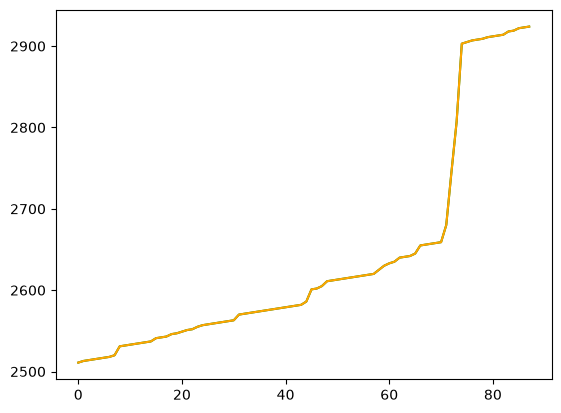

In [10]:
# plot land and plant production before and after the scaling
import matplotlib.pyplot as plt

vegetable_products_scaled = fbs_scaled.Item.loc[fbs_scaled.Item_origin == 'Vegetal Products'].values
vegetable_products = fbs.Item.loc[fbs.Item_origin == 'Vegetal Products'].values

# vegetable_land_scaled = land_scaled.loc[vegetable_products_scaled].sum(dim='Item')
# vegetable_land = land.loc[vegetable_products].sum(dim='Item')

# vegetable_land_scaled.plot(label='Scaled Land', color='green')
# vegetable_land.plot(label='Original Land', color='orange')

plt.plot(vegetable_products_scaled, label='Scaled Vegetable Products', color='green')
plt.plot(vegetable_products, label='Original Vegetable Products', color='orange')